In [1]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/brian/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


/home/brian/Documents/projects/applied-machine-learning/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Use OpenCV to explore and load the dataset
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Root path that KaggleHub downloaded for us (from the previous cell)
print("Dataset root:", path)
# list all files in the root directory
print("Files in root:", os.listdir(path))

Dataset root: /home/brian/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2
Files in root: ['seg_pred', 'seg_test', 'seg_train']


In [3]:
train_dir_labels = os.path.join(path, "seg_train", "seg_train")
print('dataset labels')
print(os.listdir(train_dir_labels))

dataset labels
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Assignment constants: image size and class names
IMGSIZE = (128, 128)  # (width, height)
CLASS_NAMES = train_dir_labels

print("IMGSIZE:", IMGSIZE)
print("Class names:", CLASS_NAMES)


IMGSIZE: (128, 128)
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [5]:
# Load and resize training and testing images to IMGSIZE

def load_split_images(root_path, split_name, img_size, class_names):
    X, y = [], []
    base_dir = os.path.join(root_path, split_name, split_name)
    for label_name in class_names:
        class_dir = os.path.join(base_dir, label_name)
        for f in sorted(os.listdir(class_dir)):
            if not f.lower().endswith('.jpg'):
                continue
            img_path = os.path.join(class_dir, f)
            img = cv2.imread(img_path)  # BGR
            if img is None:
                continue
            img_resized = cv2.resize(img, img_size)
            X.append(img_resized)
            y.append(class_names.index(label_name))
    X = np.stack(X, axis=0)  # shape: (N, H, W, C)
    y = np.array(y, dtype=np.int64)
    return X, y

X_tr, y_tr = load_split_images(path, 'seg_train', IMGSIZE, CLASS_NAMES)
X_ts, y_ts = load_split_images(path, 'seg_test', IMGSIZE, CLASS_NAMES)

print("Train images shape:", X_tr.shape)
print("Train labels shape:", y_tr.shape)
print("Test images shape:", X_ts.shape)
print("Test labels shape:", y_ts.shape)


Train images shape: (14034, 128, 128, 3)
Train labels shape: (14034,)
Test images shape: (3000, 128, 128, 3)
Test labels shape: (3000,)


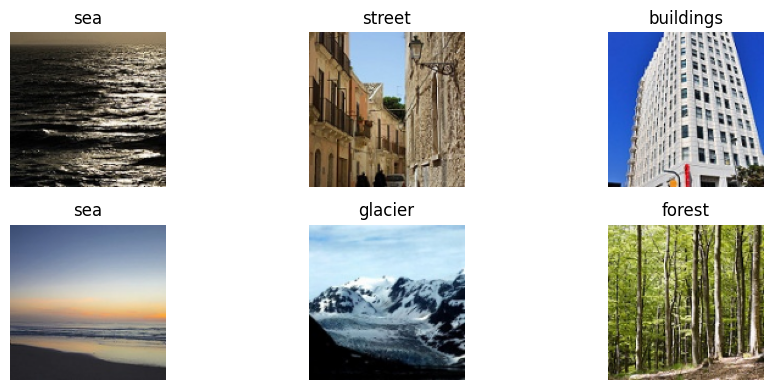

Example image shape (H, W, C): (128, 128, 3)
Number of color channels: 3


In [25]:
# Display a few example images and answer: how many color channels?
import random

num_examples = 6
example_image_indexes = random.sample(range(X_tr.shape[0]), num_examples)
plt.figure(figsize=(10, 4))

for i, val in enumerate(example_image_indexes):
    img_bgr = X_tr[val]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(CLASS_NAMES[y_tr[val]])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Example image shape (H, W, C):", X_tr[0].shape)
print("Number of color channels:", X_tr[0].shape[2])


In [7]:
# Convert the image sets to NumPy arrays and scale to [0, 1]

# X_tr and X_ts are already NumPy arrays of shape (N, 128, 128, 3)
print("Training array shape:", X_tr.shape)
print("Testing array shape:", X_ts.shape)

# Convert to float32 and scale pixel values to [0, 1]
X_tr_scaled = X_tr.astype('float32') / 255.0
X_ts_scaled = X_ts.astype('float32') / 255.0

print("Scaled training min/max:", X_tr_scaled.min(), X_tr_scaled.max())
print("Scaled testing min/max:", X_ts_scaled.min(), X_ts_scaled.max())


Training array shape: (14034, 128, 128, 3)
Testing array shape: (3000, 128, 128, 3)
Scaled training min/max: 0.0 1.0
Scaled testing min/max: 0.0 1.0


In [ ]:
# simple neural network - prepare data for PyTorch

import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
# use permute to move color channels to the first dimension (N, color, height, width)
X_train_tensor = torch.from_numpy(X_tr_scaled).permute(0, 3, 1, 2) 
y_train_tensor = torch.from_numpy(y_tr).long()
X_test_tensor = torch.from_numpy(X_ts_scaled).permute(0, 3, 1, 2)
y_test_tensor = torch.from_numpy(y_ts).long()

print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

# Create TensorDataset and DataLoader
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Train tensor shape: torch.Size([14034, 3, 128, 128])
Test tensor shape: torch.Size([3000, 3, 128, 128])
Number of training batches: 55
Number of testing batches: 12


In [9]:
# simple neural network model definition

import torch.nn as nn

input_dim = 128 * 128 * 3
hidden_dim = 50  
num_classes = len(CLASS_NAMES)

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        # x has shape (batch_size, C, H, W); flatten to (batch_size, C*H*W)
        x_flat = torch.flatten(x, start_dim=1)
        return self.net(x_flat)

# add devices, I work from my laptop sometimes I need to check for both
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP(input_dim, hidden_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=49152, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=6, bias=True)
  )
)


In [10]:
# simple neural network training loop

def train_model(model, optimizer, train_loader, device, num_epochs=100):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, preds = outputs.max(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")


In [11]:
train_model(model, optimizer, train_loader, device, num_epochs=100)

Epoch 10/100 - loss: 1.0328 - acc: 0.6060
Epoch 20/100 - loss: 0.8633 - acc: 0.6734
Epoch 30/100 - loss: 0.7508 - acc: 0.7193
Epoch 40/100 - loss: 0.6587 - acc: 0.7526
Epoch 50/100 - loss: 0.5643 - acc: 0.7903
Epoch 60/100 - loss: 0.4780 - acc: 0.8219
Epoch 70/100 - loss: 0.4374 - acc: 0.8402
Epoch 80/100 - loss: 0.4586 - acc: 0.8333
Epoch 90/100 - loss: 0.3277 - acc: 0.8790
Epoch 100/100 - loss: 0.2974 - acc: 0.8898


In [ ]:
# simple neural network evaluation on test set

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            _, preds = outputs.max(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_accuracy = correct / total
    print(f"Test accuracy: {test_accuracy:.4f}")


In [ ]:
evaluate_model(model, test_loader, device)

Test accuracy: 0.5590



## How can we improve this model

The primary issue with the initial model, which I learned from this weeks discussion, is that MLPs are not well-suited for image data because they require flattening the input immediately, which removes the spatial relationships between pixels. A fully connected layer treats a pixel at the top-left and one in the center as equally related, missing the local patterns like edges and textures that define an image. To solve this, I implemented a Convolutional Neural Network (CNN) instead. By using `Conv2d` layers, the model can scan the image with learnable filters to detect features regardless of their position, while `MaxPool2d` layers progressively reduce the image size to focus on the most important details. This hierarchical approach allows the network to learn simple shapes in early layers and complex objects in deeper layers, which is far more effective for visual tasks.

To further improve performance and prevent overfitting—a common issue where the model memorizes training images—I added `Dropout` layers to the classifier. This forces the network to learn robust features by randomly disabling neurons during training, ensuring it doesn't rely too heavily on any single pattern. I also increased the depth of the network, moving from 32 to 128 filters, which gives the model enough capacity to distinguish between the six different classes. This combination of preserving spatial structure through convolutions and enforcing regularization with dropout provides a much more powerful and generalized solution than the original MLP.

In [ ]:
import torch.nn as nn

num_classes = len(CLASS_NAMES)

class SimpleCNNWithDropout(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # feature extractor: conv + pool layers
        self.features = nn.Sequential(
            # we need padding 1 to keep the same output size since we are using a 3x3 kernel, 128 x 128
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # (32, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(2), # now (32, 64, 64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (64, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2), # now (64, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (128, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2), # now (128, 16, 16)
        )
        # classifier: flatten + fully connected with dropout
        self.classifier = nn.Sequential(
            nn.Flatten(), # 16 x 16 x 128 = 32768
            nn.Dropout(0.5),
            nn.Linear(128 * 16 * 16, 256), # 23768 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# device + optimizer stay the same interface as before
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_with_dropout = SimpleCNNWithDropout(num_classes).to(device)
optimizer_dropout = torch.optim.Adam(
    model_with_dropout.parameters(),
    lr=3e-4,          # slightly smaller LR for CNN
    weight_decay=1e-4 # modest L2 regularization
)

print(model_with_dropout)

SimpleCNNWithDropout(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=32768, out_features=256, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [17]:
# Train here
print(device)

cuda


In [18]:
train_model(model_with_dropout, optimizer_dropout, train_loader, device, num_epochs=100)

Epoch 10/100 - loss: 0.4218 - acc: 0.8472
Epoch 20/100 - loss: 0.2910 - acc: 0.8961
Epoch 30/100 - loss: 0.2070 - acc: 0.9276
Epoch 40/100 - loss: 0.1393 - acc: 0.9526
Epoch 50/100 - loss: 0.1100 - acc: 0.9629
Epoch 60/100 - loss: 0.0710 - acc: 0.9771
Epoch 70/100 - loss: 0.0629 - acc: 0.9796
Epoch 80/100 - loss: 0.0442 - acc: 0.9857
Epoch 90/100 - loss: 0.0473 - acc: 0.9842
Epoch 100/100 - loss: 0.0378 - acc: 0.9868


In [19]:
evaluate_model(model_with_dropout, test_loader, device)

Test accuracy: 0.8293
